## Code to calculate the RBP Activity Metric and generate heatmap figure

### Load packages and read in table

In [1]:
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import seaborn as sns
import pickle
from sklearn.metrics import matthews_corrcoef
from pathlib import Path
from scipy.stats import fisher_exact

### Function to get path for big table

In [4]:
def get_path(cell_line):
    """
    Returns the full path to the cell line data directory,
    relative to this script's location.
    
    Args:
        cell_line (str): The name of the cell line (e.g. "K562" or "HepG2").
    
    Returns:
        str: Full path to the data file for the given cell line.
    """
    data_dir = Path("../../06_first_order_SHAP_analysis/outputs/FINAL_AVERAGE_SHAP_CACHE")

    return str(data_dir / f"{cell_line}_all-data.feather")

### Read in data for both cell lines

In [5]:
data_path_HepG2 = get_path("HepG2")
all_model_data_HepG2 = pl.read_ipc(data_path_HepG2)

FileNotFoundError: No such file or directory (os error 2): .../../06_first_order_SHAP_analysis/outputs/FINAL_AVERAGE_SHAP_CACHE/HepG2_all-data.feather (set POLARS_VERBOSE=1 to see full path)

In [4]:
data_path_K562 = get_path("K562")
all_model_data_K562 = pl.read_ipc(data_path_K562)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


# SHAP vs RBP Activity Score

### This has the new SHAP data (log odds units)

In [7]:
glossary_data_path = f"../../06_first_order_SHAP_analysis/outputs/specialized_global_SHAP/signed_local_SHAP_mean_bound_only_unique_binding.pkl"

with open(glossary_data_path, 'rb') as f:
        data = pickle.load(f)

In [8]:
keys = list(data.keys())

HepG2_glossary = pd.DataFrame(data[keys[0]])
K562_glossary = pd.DataFrame(data[keys[1]])

HepG2_glossary.columns.name = None
K562_glossary.columns.name = None

## Scatterplot RBP Activity vs SHAP

In [42]:
# Plot Scatterplot with MCC

def scatterplot(cell_line, data):
    
    print(cell_line)
    
    # Filter massive dataframe for KD samples, FDR <= 0.1, abs[DeltaPSI] > 0.

    filtered_data = (
        data
        .filter(
            (data["Sample Name"].str.contains("KD", literal=True))
            & (data["FDR"] <= 0.1)
            & (data["DeltaPSI"].abs() > 0)
        )    
    )

    # Columns 
    columns_to_keep = [
        "RBP_KD_Target",
        "Sample Name",
        "FDR",
        "DeltaPSI",
        "has_RBP_KD_1",
        "has_RBP_KD_2",
        "has_RBP_KD_3",
        "has_RBP_KD_4",
        "has_RBP_KD_5",
        "has_RBP_KD_6",
        "Raw P-Val",
        "rMATS Event ID"
    ]
    
    rbp_targets = (
        filtered_data["RBP_KD_Target"]
        .unique()
        .sort()
        .to_list()
    )
    
    positions = [1,2,3,4,5,6]

    results = []  # collect all results here

    for rbp in rbp_targets:
        for pos in positions:

            rbp_specific_data = (
            filtered_data
            .filter(
                (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
            .unique(subset=["rMATS Event ID"])) # gets in-silico KD rows per RBP per position

            # Drop unneccesary columns
            rbp_specific_data = rbp_specific_data.select(columns_to_keep)

            # Convert to pandas
            df = rbp_specific_data.to_pandas()

            # Prevents error for no data (SAFB or IGF..1)
            data = df["DeltaPSI"]

            if data.empty:
                continue 

            # DPSI conversion
            df["DeltaPSI"] = df["DeltaPSI"] * -1

            # Calculate the number of positive dPSI and the number of negative dPSI

            num_pos = (df["DeltaPSI"] > 0).sum()
            num_neg = (df["DeltaPSI"] < 0).sum()

            # Do not include rows plots with less than 10 sig. points 

            if (num_pos + num_neg) < 10:
                continue 

            # Normalized Difference Score
            norm_diff = (num_pos - num_neg) / (num_pos + num_neg)

            # Append results
            results.append({
                "RBP": rbp,
                "Position": pos,
                "num_pos": num_pos,
                "num_neg": num_neg,
                "norm_diff": norm_diff
            })

    # Final results dataframe
    results_df = pd.DataFrame(results)
    
    df = pd.DataFrame(results_df)

    glossary_data = globals()[f"{cell_line}_glossary"]
    glossary_data = glossary_data.reset_index()
    
    # Melt glossary from wide to long so it matches activity data structure

    glossary_long = glossary_data.melt(id_vars="Position", var_name="RBP", value_name="shap")

    # Merge on position + RBP

    merged = df.merge(glossary_long, on=["RBP", "Position"], how="left")
    
    
    merged["pred_sign"] = np.sign(merged["shap"])
    merged["true_sign"] = np.sign(merged["norm_diff"])
    
    # Drop zeros
    merged_mcc = merged[(merged["pred_sign"] != 0) & (merged["true_sign"] != 0)]
    
    # Fisher's Exact Test (2x2 contingency table on same sign-filtered data)
    # Binarize: positive sign = 1, negative sign = 0
    pred_pos = merged_mcc["pred_sign"] == 1
    pred_neg = merged_mcc["pred_sign"] == -1
    true_pos = merged_mcc["true_sign"] == 1
    true_neg = merged_mcc["true_sign"] == -1
    
    tp = (pred_pos & true_pos).sum()   # Q1: both positive
    fp = (pred_pos & true_neg).sum()   # Q4: pred+, true-
    fn = (pred_neg & true_pos).sum()   # Q2: pred-, true+
    tn = (pred_neg & true_neg).sum()   # Q3: both negative
    
    contingency_table = [[tp, fp], [fn, tn]]
    odds_ratio, fisher_p = fisher_exact(contingency_table, alternative='two-sided')
    print(f"Fisher's Exact Test: OR = {odds_ratio:.4f}, p = {fisher_p:.4e}")
    
    # Scatterplot
    conditions = [
        (merged["shap"] > 0) & (merged["norm_diff"] > 0),   # Q1
        (merged["shap"] < 0) & (merged["norm_diff"] > 0),   # Q2
        (merged["shap"] < 0) & (merged["norm_diff"] < 0),   # Q3
        (merged["shap"] > 0) & (merged["norm_diff"] < 0),   # Q4
    ]
    colors = ["red", "gray", "blue", "gray"]
    merged["quadrant_color"] = np.select(conditions, colors, default="black")
    
    # Count quadrant points
    q1 = ((merged["shap"] > 0) & (merged["norm_diff"] > 0)).sum()
    q3 = ((merged["shap"] < 0) & (merged["norm_diff"] < 0)).sum()
    
    total_points = len(merged)
    
    conc = ((q1 + q3) / total_points) if q3 != 0 else np.nan
    conc = conc * 100
    
    # Format p-value for display
    if fisher_p < 0.001:
        p_str = f"{fisher_p:.2e}"
    else:
        p_str = f"{fisher_p:.4f}"
    
    label = r'Avg. SHAP'
    score = r'Activity'
    plt.style.use("../../paper.mplstyle")
    plt.figure(figsize=(8, 6))
    plt.scatter(merged["shap"], merged["norm_diff"], c=merged["quadrant_color"], alpha=0.5)
    plt.xlim(-1.5, 1.3)
    plt.ylim(-1.05, 1.05)
    
    # Add horizontal & vertical lines at 0 to create 4 quadrants
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    
    # Labels & title
    plt.xlabel(label, fontsize=21, labelpad=15)
    plt.ylabel(score, fontsize=21, labelpad=15)
    ax = plt.gca()
    ax.text(0.02, 0.97, f"{cell_line}", transform=ax.transAxes,
            fontsize=22, fontweight='bold', va='top', ha='left')
    
    ax.text(
        0.98, 0.03,
        f"Sign Concordance: {conc:.1f}%",
        # f"FET P-Value = {p_str}",
        transform=ax.transAxes,
        fontsize=15,
        va='bottom',
        ha='right',
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="none",
            edgecolor="lightgray",
            alpha=0.6
        )
    )
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.savefig(f"{cell_line}_scatterplot.pdf", bbox_inches='tight')
    plt.show()

K562
Fisher's Exact Test: OR = 4.3333, p = 2.4189e-02


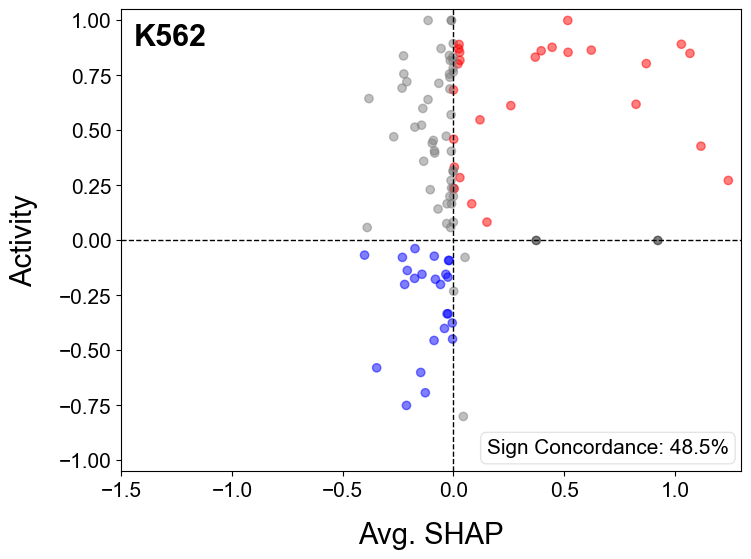

In [43]:
scatterplot('K562', all_model_data_K562)

HepG2
Fisher's Exact Test: OR = 1.6541, p = 3.6250e-01


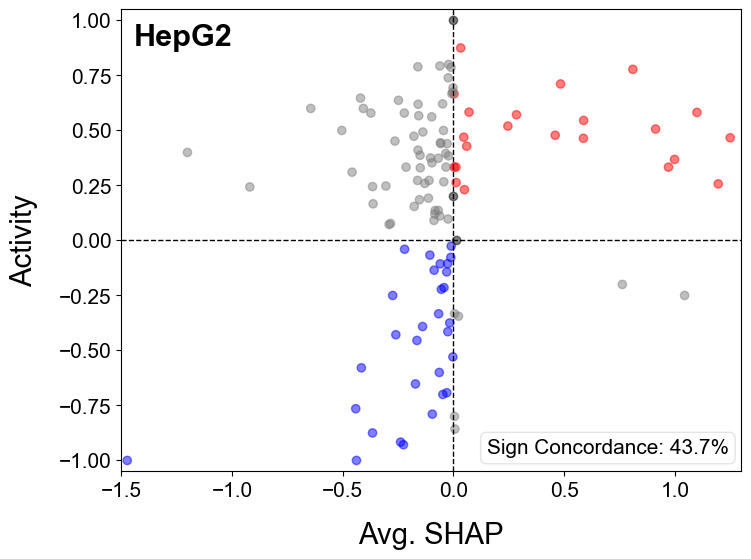

In [44]:
scatterplot('HepG2', all_model_data_HepG2)

### Scatterplots with buffer along axis

In [12]:
def scatterplot_buff(cell_line, data):
    
    print(cell_line)
    
    filtered_data = (
        data
        .filter(
            (data["Sample Name"].str.contains("KD", literal=True))
            & (data["FDR"] <= 0.1)
            & (data["DeltaPSI"].abs() > 0)
        )    
    )

    columns_to_keep = [
        "RBP_KD_Target",
        "Sample Name",
        "FDR",
        "DeltaPSI",
        "has_RBP_KD_1",
        "has_RBP_KD_2",
        "has_RBP_KD_3",
        "has_RBP_KD_4",
        "has_RBP_KD_5",
        "has_RBP_KD_6",
        "Raw P-Val",
        "rMATS Event ID"
    ]
    
    rbp_targets = (
        filtered_data["RBP_KD_Target"]
        .unique()
        .sort()
        .to_list()
    )
    
    positions = [1,2,3,4,5,6]

    results = []

    for rbp in rbp_targets:
        for pos in positions:

            rbp_specific_data = (
            filtered_data
            .filter(
                (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
            .unique(subset=["rMATS Event ID"]))

            rbp_specific_data = rbp_specific_data.select(columns_to_keep)
            df = rbp_specific_data.to_pandas()
            data = df["DeltaPSI"]

            if data.empty:
                continue 

            df["DeltaPSI"] = df["DeltaPSI"] * -1

            num_pos = (df["DeltaPSI"] > 0).sum()
            num_neg = (df["DeltaPSI"] < 0).sum()

            if (num_pos + num_neg) < 10:
                continue 

            norm_diff = (num_pos - num_neg) / (num_pos + num_neg)

            results.append({
                "RBP": rbp,
                "Position": pos,
                "num_pos": num_pos,
                "num_neg": num_neg,
                "norm_diff": norm_diff
            })

    results_df = pd.DataFrame(results)
    df = pd.DataFrame(results_df)

    glossary_data = globals()[f"{cell_line}_glossary"]
    glossary_data = glossary_data.reset_index()
    
    glossary_long = glossary_data.melt(id_vars="Position", var_name="RBP", value_name="shap")
    merged = df.merge(glossary_long, on=["RBP", "Position"], how="left")
    
    # --- Buffer zone definition ---
    BUFFER = 0.025
    in_buffer = (merged["shap"].abs() <= BUFFER) | (merged["norm_diff"].abs() <= BUFFER)
    outside_buffer = ~in_buffer

    # --- Fisher's Exact Test (outside buffer only) ---
    merged_mcc = merged[outside_buffer].copy()
    merged_mcc["pred_sign"] = np.sign(merged_mcc["shap"])
    merged_mcc["true_sign"] = np.sign(merged_mcc["norm_diff"])

    pred_pos = merged_mcc["pred_sign"] == 1
    pred_neg = merged_mcc["pred_sign"] == -1
    true_pos = merged_mcc["true_sign"] == 1
    true_neg = merged_mcc["true_sign"] == -1
    
    tp = (pred_pos & true_pos).sum()
    fp = (pred_pos & true_neg).sum()
    fn = (pred_neg & true_pos).sum()
    tn = (pred_neg & true_neg).sum()
    
    contingency_table = [[tp, fp], [fn, tn]]
    odds_ratio, fisher_p = fisher_exact(contingency_table, alternative='two-sided')
    print(f"Fisher's Exact Test: OR = {odds_ratio:.4f}, p = {fisher_p:.4e}")
    
    # --- Sign concordance (outside buffer only) ---
    q1 = ((merged_mcc["shap"] > 0) & (merged_mcc["norm_diff"] > 0)).sum()
    q3 = ((merged_mcc["shap"] < 0) & (merged_mcc["norm_diff"] < 0)).sum()
    total_outside = len(merged_mcc)
    
    conc = ((q1 + q3) / total_outside) * 100 if total_outside > 0 else np.nan

    # --- Color assignment (all points) ---
    conditions = [
        in_buffer,                                                              # buffer  → green
        (~in_buffer) & (merged["shap"] > 0) & (merged["norm_diff"] > 0),       # Q1      → red
        (~in_buffer) & (merged["shap"] < 0) & (merged["norm_diff"] > 0),       # Q2      → gray
        (~in_buffer) & (merged["shap"] < 0) & (merged["norm_diff"] < 0),       # Q3      → blue
        (~in_buffer) & (merged["shap"] > 0) & (merged["norm_diff"] < 0),       # Q4      → gray
    ]
    colors = ["green", "red", "gray", "blue", "gray"]
    merged["quadrant_color"] = np.select(conditions, colors, default="black")
    
    # --- Format p-value ---
    if fisher_p < 0.001:
        p_str = f"{fisher_p:.2e}"
    else:
        p_str = f"{fisher_p:.4f}"
    
    label = r'Avg. SHAP'
    score = r'Activity'
    plt.style.use("../../paper.mplstyle")
    plt.figure(figsize=(8, 6))
    plt.scatter(merged["shap"], merged["norm_diff"], c=merged["quadrant_color"], alpha=0.5)
    plt.xlim(-1.5, 1.3)
    plt.ylim(-1.05, 1.05)
    
    # Quadrant lines
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    
    # Buffer zone lines
    for val in [-BUFFER, BUFFER]:
        plt.axhline(val, color="green", linestyle=":", linewidth=0.8, alpha=0.6)
        plt.axvline(val, color="green", linestyle=":", linewidth=0.8, alpha=0.6)

    plt.xlabel(label, fontsize=21, labelpad=15)
    plt.ylabel(score, fontsize=21, labelpad=15)
    ax = plt.gca()
    ax.text(0.02, 0.97, f"{cell_line}", transform=ax.transAxes,
            fontsize=22, fontweight='bold', va='top', ha='left')
    
    ax.text(
        0.98, 0.03,
        f"Sign Concordance: {conc:.1f}%",
        transform=ax.transAxes,
        fontsize=15,
        va='bottom',
        ha='right',
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="none",
            edgecolor="lightgray",
            alpha=0.6
        )
    )
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.show()

HepG2
Fisher's Exact Test: OR = 3.1837, p = 1.0595e-01


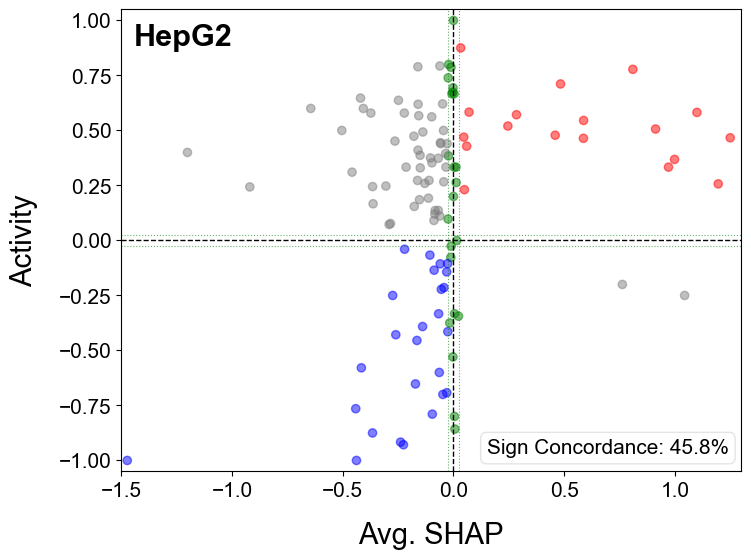

In [13]:
scatterplot_buff('HepG2', all_model_data_HepG2)

K562
Fisher's Exact Test: OR = 7.9167, p = 4.7860e-03


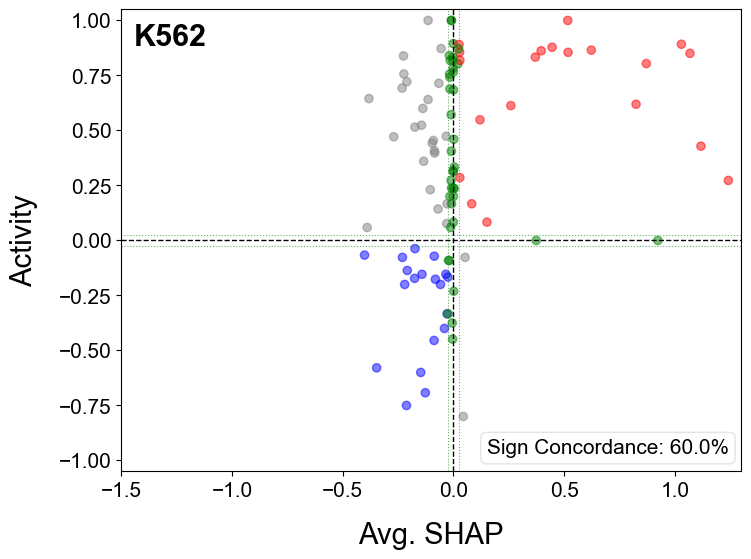

In [14]:
scatterplot_buff('K562', all_model_data_K562)